# LumenY 5.2 — 3-Quantile Regression (4H) — All 15 Pairs

Exact replica of `notebooks_5/02.1_model_training.ipynb` but trained on **all 15 pairs**
(7 majors from features_2 + 8 crosses from features_3).

**Models saved to:** `backend/models_5.1/3_quants/`

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_pinball_loss

FEATURES_DIR_MAJORS = Path('../backend/data/features_2')
FEATURES_DIR_CROSSES = Path('../backend/data/features_3')
MODELS_DIR   = Path('../backend/models_5.2/3_quants')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

QUANTILES = [0.25, 0.50, 0.75]
QUANTILE_NAMES = ['Q25', 'Q50', 'Q75']

# -- CRITICAL: Training cutoff --
TRAIN_END = '2024-06-30'
AVG_SPREAD = 0.00028

print('Ready.')
print(f'Models to train: {len(QUANTILES)} quantile models (4H horizon)')
print(f'Training cutoff: {TRAIN_END}')

Ready.
Models to train: 3 quantile models (1H horizon)
Training cutoff: 2024-06-30


## 1. Load Microstructure Dataset

In [ ]:
# Load from BOTH feature directories (majors + crosses = 15 pairs)
df_majors = pd.read_parquet(FEATURES_DIR_MAJORS / 'all_pairs_microstructure.parquet')
df_crosses = pd.read_parquet(FEATURES_DIR_CROSSES / 'all_pairs_microstructure.parquet')

print(f'Majors:  {df_majors.shape} — pairs: {df_majors["pair"].unique()}')
print(f'Crosses: {df_crosses.shape} — pairs: {df_crosses["pair"].unique()}')

df = pd.concat([df_majors, df_crosses]).sort_index()
del df_majors, df_crosses

label_cols   = [c for c in df.columns if c.startswith('label_')]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]

TARGET_COL = 'label_4H'

# Split
df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index > TRAIN_END].copy()

print(f'\nFull dataset:  {df.shape}  ({df.index.min().date()} to {df.index.max().date()})')
print(f'Features:      {len(feature_cols)}')
print(f'Train set:     {len(df_train):,} rows  ({df_train.index.min().date()} to {df_train.index.max().date()})')
print(f'Test set:      {len(df_test):,} rows  ({df_test.index.min().date()} to {df_test.index.max().date()})')
print(f'All pairs:     {sorted(df["pair"].unique())}')
print(f'\nTarget stats (train):')
print(df_train[TARGET_COL].describe())

Majors:  (702117, 67) — pairs: <ArrowStringArray>
['EURUSD', 'USDCHF', 'USDCAD', 'NZDUSD', 'GBPUSD', 'AUDUSD', 'USDJPY']
Length: 7, dtype: str
Crosses: (815903, 67) — pairs: <ArrowStringArray>
['EURJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD',
 'GBPJPY']
Length: 8, dtype: str

Full dataset:  (1518020, 67)  (2009-09-25 to 2025-12-31)
Features:      64
Train set:     1,378,758 rows  (2009-09-25 to 2024-06-28)
Test set:      139,262 rows  (2024-06-30 to 2025-12-31)
All pairs:     ['AUDJPY', 'AUDNZD', 'AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']

Target stats (train):
count    1.335228e+06
mean    -1.540284e-06
std      1.540340e-03
min     -2.371324e-01
25%     -5.422861e-04
50%      6.150289e-06
75%      5.523941e-04
max      1.831588e-01
Name: label_1H, dtype: float64


## 2. Walk-Forward Splits

In [3]:
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    """Expanding window walk-forward splits. All within training data."""
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

splits = walk_forward_splits(len(df_train))
print(f'Walk-forward splits: {len(splits)} (all within training set, before {TRAIN_END})')
for i, (train_idx, test_idx) in enumerate(splits):
    print(f'  Fold {i+1}: Train -> {df_train.index[train_idx[-1]].date()} ({len(train_idx):,}) | '
          f'Test {df_train.index[test_idx[0]].date()} -> {df_train.index[test_idx[-1]].date()} ({len(test_idx):,})')

Walk-forward splits: 5 (all within training set, before 2024-06-30)
  Fold 1: Train -> 2017-02-28 (689,379) | Test 2017-02-28 -> 2018-08-21 (137,875)
  Fold 2: Train -> 2018-08-21 (827,254) | Test 2018-08-21 -> 2020-02-20 (137,875)
  Fold 3: Train -> 2020-02-20 (965,129) | Test 2020-02-20 -> 2021-08-25 (137,875)
  Fold 4: Train -> 2021-08-25 (1,103,004) | Test 2021-08-25 -> 2023-01-25 (137,875)
  Fold 5: Train -> 2023-01-25 (1,240,879) | Test 2023-01-25 -> 2024-06-28 (137,875)


## 3. LightGBM Quantile Config

In [4]:
def get_lgbm_params(quantile):
    return {
        'objective':         'quantile',
        'alpha':             quantile,
        'metric':            'quantile',
        'boosting_type':     'gbdt',
        'n_estimators':      5000,
        'learning_rate':     0.02,
        'num_leaves':        64,
        'max_depth':         6,
        'min_child_samples': 50,
        'feature_fraction':  0.7,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'reg_alpha':         0.1,
        'reg_lambda':        0.1,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'device':            'gpu',
    }

print('Params ready. objective=quantile with pinball loss.')

Params ready. objective=quantile with pinball loss.


## 4. Train 3 Quantile Models (Walk-Forward CV + Final)

In [5]:
y_all = df_train[TARGET_COL]
valid_mask = y_all.notna()
X_clean = df_train[feature_cols][valid_mask].ffill().fillna(0)
y_clean = y_all[valid_mask]

print(f'Training samples: {len(X_clean):,} (all before {TRAIN_END})')
print(f'Target mean: {y_clean.mean():.6f}, std: {y_clean.std():.6f}')

splits = walk_forward_splits(len(X_clean))
oof_preds  = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}
best_iters = {q: [] for q in QUANTILES}
cv_pinball = {q: [] for q in QUANTILES}

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'\nTraining {q_name} (alpha={q})...')
    params = get_lgbm_params(q)

    for fold, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X_clean.iloc[train_idx], y_clean.iloc[train_idx]
        X_te, y_te = X_clean.iloc[test_idx], y_clean.iloc[test_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

        preds = model.predict(X_te)
        oof_preds[q][test_idx] = preds
        cv_pinball[q].append(mean_pinball_loss(y_te, preds, alpha=q))
        best_iters[q].append(model.best_iteration_)

    print(f'  CV Pinball: {np.mean(cv_pinball[q]):.6f} | Best iters: {best_iters[q]}')
    del model; gc.collect()

# Train final models on ALL training data
print(f'\n{"="*55}')
print('Training final models on full training set...')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    avg_iter = max(50, int(np.mean(best_iters[q])))
    params = get_lgbm_params(q)
    final_model = lgb.LGBMRegressor(**{**params, 'n_estimators': avg_iter})
    final_model.fit(X_clean, y_clean)

    q_int = int(q * 100)
    joblib.dump({
        'model': final_model,
        'quantile': q,
        'horizon': '1H',
        'feature_cols': feature_cols,
        'train_end': TRAIN_END,
        'avg_spread': AVG_SPREAD,
        'cv_pinball': np.mean(cv_pinball[q]),
        'n_iters': avg_iter,
    }, MODELS_DIR / f'model_1H_Q{q_int}.joblib')

    size_mb = (MODELS_DIR / f'model_1H_Q{q_int}.joblib').stat().st_size / 1024 / 1024
    print(f'  {q_name}: {avg_iter} iters, pinball={np.mean(cv_pinball[q]):.6f}, saved ({size_mb:.1f} MB)')
    del final_model; gc.collect()

print(f'\nAll 3 models saved to {MODELS_DIR}')

Training samples: 1,335,228 (all before 2024-06-30)
Target mean: -0.000002, std: 0.001540

Training Q25 (alpha=0.25)...
  CV Pinball: 0.000327 | Best iters: [417, 495, 157, 632, 811]

Training Q50 (alpha=0.5)...
  CV Pinball: 0.000385 | Best iters: [245, 279, 296, 1148, 1203]

Training Q75 (alpha=0.75)...
  CV Pinball: 0.000313 | Best iters: [396, 428, 520, 1150, 1170]

Training final models on full training set...
  Q25: 502 iters, pinball=0.000327, saved (2.8 MB)
  Q50: 634 iters, pinball=0.000385, saved (3.2 MB)
  Q75: 732 iters, pinball=0.000313, saved (4.0 MB)

All 3 models saved to ..\backend\models_5.1\3_quants


## 5. Quantile Coverage (OOF Calibration)

OOF Quantile Coverage:
Quantile   Target     Actual     Gap
------------------------------------------
Q25        0.25       0.240      -0.010  OK
Q50        0.50       0.496      -0.004  OK
Q75        0.75       0.752      +0.002  OK


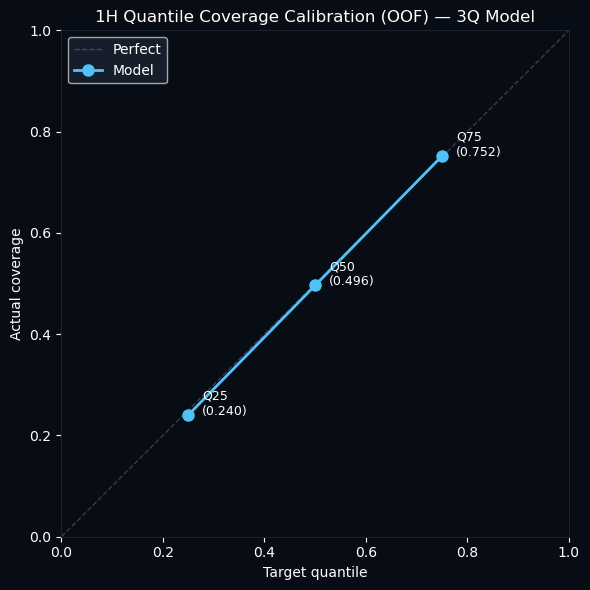

In [6]:
valid_oof = ~np.isnan(oof_preds[QUANTILES[0]])
y_oof = y_clean.values[valid_oof]

print(f'OOF Quantile Coverage:')
print(f'{"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
print(f'{"-"*42}')

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    preds_oof = oof_preds[q][valid_oof]
    coverage  = np.mean(y_oof <= preds_oof)
    gap       = coverage - q
    flag      = 'OK' if abs(gap) < 0.03 else 'NEEDS CALIBRATION'
    print(f'{q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')

# Calibration plot
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

targets = QUANTILES
actuals = [np.mean(y_oof <= oof_preds[q][valid_oof]) for q in QUANTILES]

ax.plot([0,1], [0,1], '--', color=(1,1,1,0.2), linewidth=1, label='Perfect')
ax.plot(targets, actuals, 'o-', color='#4fc3f7', linewidth=2, markersize=8, label='Model')
for t, a, name in zip(targets, actuals, QUANTILE_NAMES):
    ax.annotate(f'{name}\n({a:.3f})', (t, a), textcoords='offset points',
                xytext=(10, 0), color='white', fontsize=9)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Target quantile', color='white')
ax.set_ylabel('Actual coverage', color='white')
ax.set_title('1H Quantile Coverage Calibration (OOF) — 3Q Model', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2332', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

Load final models, predict all 3 quantiles on unseen test set.

**Trading rules:**
- Direction = sign(Q50)
- Trade only when |Q50| > spread
- PnL per trade = direction × actual_return - spread

In [7]:
# -- Prepare test data --
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

# -- Predict all 3 quantiles --
q_preds_test = {}
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    q_int = int(q * 100)
    bundle = joblib.load(MODELS_DIR / f'model_1H_Q{q_int}.joblib')
    q_preds_test[q_name] = bundle['model'].predict(X_test_clean)
    print(f'{q_name}: mean={q_preds_test[q_name].mean():.6f}, std={q_preds_test[q_name].std():.6f}')

# -- Build results DataFrame --
results = pd.DataFrame({
    'actual_return': y_test_clean.values,
    'Q25': q_preds_test['Q25'],
    'Q50': q_preds_test['Q50'],
    'Q75': q_preds_test['Q75'],
    'pair': df_test.loc[valid_test, 'pair'].values,
}, index=y_test_clean.index)

results['abs_return'] = np.abs(results['actual_return'])
results['pred_dir'] = np.sign(results['Q50'])
results['actual_dir'] = np.sign(results['actual_return'])
results['abs_Q50'] = np.abs(results['Q50'])
results['iqr'] = results['Q75'] - results['Q25']  # IQR as uncertainty measure

print(f'\nTest set: {len(results):,} rows ({results.index.min().date()} -> {results.index.max().date()})')
print(f'Direction balance: {(results["actual_dir"] > 0).mean():.3f} UP')

# -- Evaluate with different |Q50| thresholds --
thresholds = {
    'All hours (no filter)': 0,
    '|Q50| > 0.5x spread':  AVG_SPREAD * 0.5,
    '|Q50| > 1x spread':    AVG_SPREAD,
    '|Q50| > 2x spread':    AVG_SPREAD * 2,
    '|Q50| > 3x spread':    AVG_SPREAD * 3,
    '|Q50| > 5x spread':    AVG_SPREAD * 5,
}

print(f'\n{"Filter":<25} {"Trades":>8} {"WinRate":>10} {"Avg|Move|":>12} {"EV/trade":>12} {"Total PnL":>12} {"Sharpe":>8}')
print('-' * 90)

for name, thresh in thresholds.items():
    mask = results['abs_Q50'] > thresh
    if mask.sum() < 50:
        continue
    s = results[mask]
    
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    win_rate = (s['pred_dir'] == s['actual_dir']).mean()
    avg_move = s['abs_return'].mean()
    ev = pnl.mean()
    total_pnl = pnl.sum()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    
    flag = ' <<<' if ev > 0 else ''
    print(f'{name:<25} {mask.sum():>8,} {win_rate:>9.1%} {avg_move:>12.6f} {ev:>12.6f} {total_pnl:>12.4f} {sharpe:>8.2f}{flag}')

print(f'\nSpread cost: {AVG_SPREAD:.5f}')
print('<<< = positive EV after spread')

Q25: mean=-0.000560, std=0.000342
Q50: mean=0.000024, std=0.000494
Q75: mean=0.000592, std=0.000811

Test set: 136,372 rows (2024-07-01 -> 2025-12-31)
Direction balance: 0.500 UP

Filter                      Trades    WinRate    Avg|Move|     EV/trade    Total PnL   Sharpe
------------------------------------------------------------------------------------------
All hours (no filter)      136,372     52.4%     0.000816    -0.000186     -25.3255    -5.38
|Q50| > 0.5x spread          9,145     61.9%     0.001836     0.000543       4.9630     5.75 <<<
|Q50| > 1x spread            2,462     73.3%     0.003692     0.002315       5.7000    13.62 <<<
|Q50| > 2x spread              986     84.9%     0.007080     0.005725       5.6446    22.07 <<<
|Q50| > 3x spread              633     88.3%     0.010247     0.008731       5.5270    27.56 <<<
|Q50| > 5x spread              418     93.8%     0.014540     0.012984       5.4274    34.40 <<<

Spread cost: 0.00028
<<< = positive EV after spread


In [8]:
# -- Per-pair breakdown (|Q50| > 1x spread filter) --
filtered = results[results['abs_Q50'] > AVG_SPREAD]

print(f'Per-pair results (|Q50| > {AVG_SPREAD:.5f}):')
print(f'\n{"Pair":<10} {"Trades":>8} {"WinRate":>10} {"Avg|Move|":>12} {"EV/trade":>12} {"Total PnL":>12} {"Sharpe":>8}')
print('-' * 75)

for pair in sorted(filtered['pair'].unique()):
    p = filtered[filtered['pair'] == pair]
    pnl = p['pred_dir'] * p['actual_return'] - AVG_SPREAD
    win_rate = (p['pred_dir'] == p['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    flag = ' <<<' if pnl.mean() > 0 else ''
    print(f'{pair:<10} {len(p):>8,} {win_rate:>9.1%} {p["abs_return"].mean():>12.6f} {pnl.mean():>12.6f} {pnl.sum():>12.4f} {sharpe:>8.2f}{flag}')

Per-pair results (|Q50| > 0.00028):

Pair         Trades    WinRate    Avg|Move|     EV/trade    Total PnL   Sharpe
---------------------------------------------------------------------------
AUDJPY          292     66.4%     0.003661     0.001831       0.5348    13.36 <<<
AUDNZD          424     86.6%     0.002664     0.002186       0.9270    20.65 <<<
AUDUSD          107     81.3%     0.003256     0.001964       0.2102    28.32 <<<
CADJPY          220     62.7%     0.005457     0.003193       0.7024    18.58 <<<
CHFJPY          327     74.9%     0.003182     0.002397       0.7838    18.39 <<<
EURAUD          125     75.2%     0.003241     0.002415       0.3018    32.01 <<<
EURGBP          165     87.3%     0.004615     0.002026       0.3344     7.63 <<<
EURJPY          135     59.3%     0.001845    -0.000200      -0.0269    -5.72
EURUSD           38     63.2%     0.002205     0.000888       0.0337    17.17 <<<
GBPJPY          177     59.3%     0.001845    -0.000185      -0.0328    -4

## 7. Equity Curves

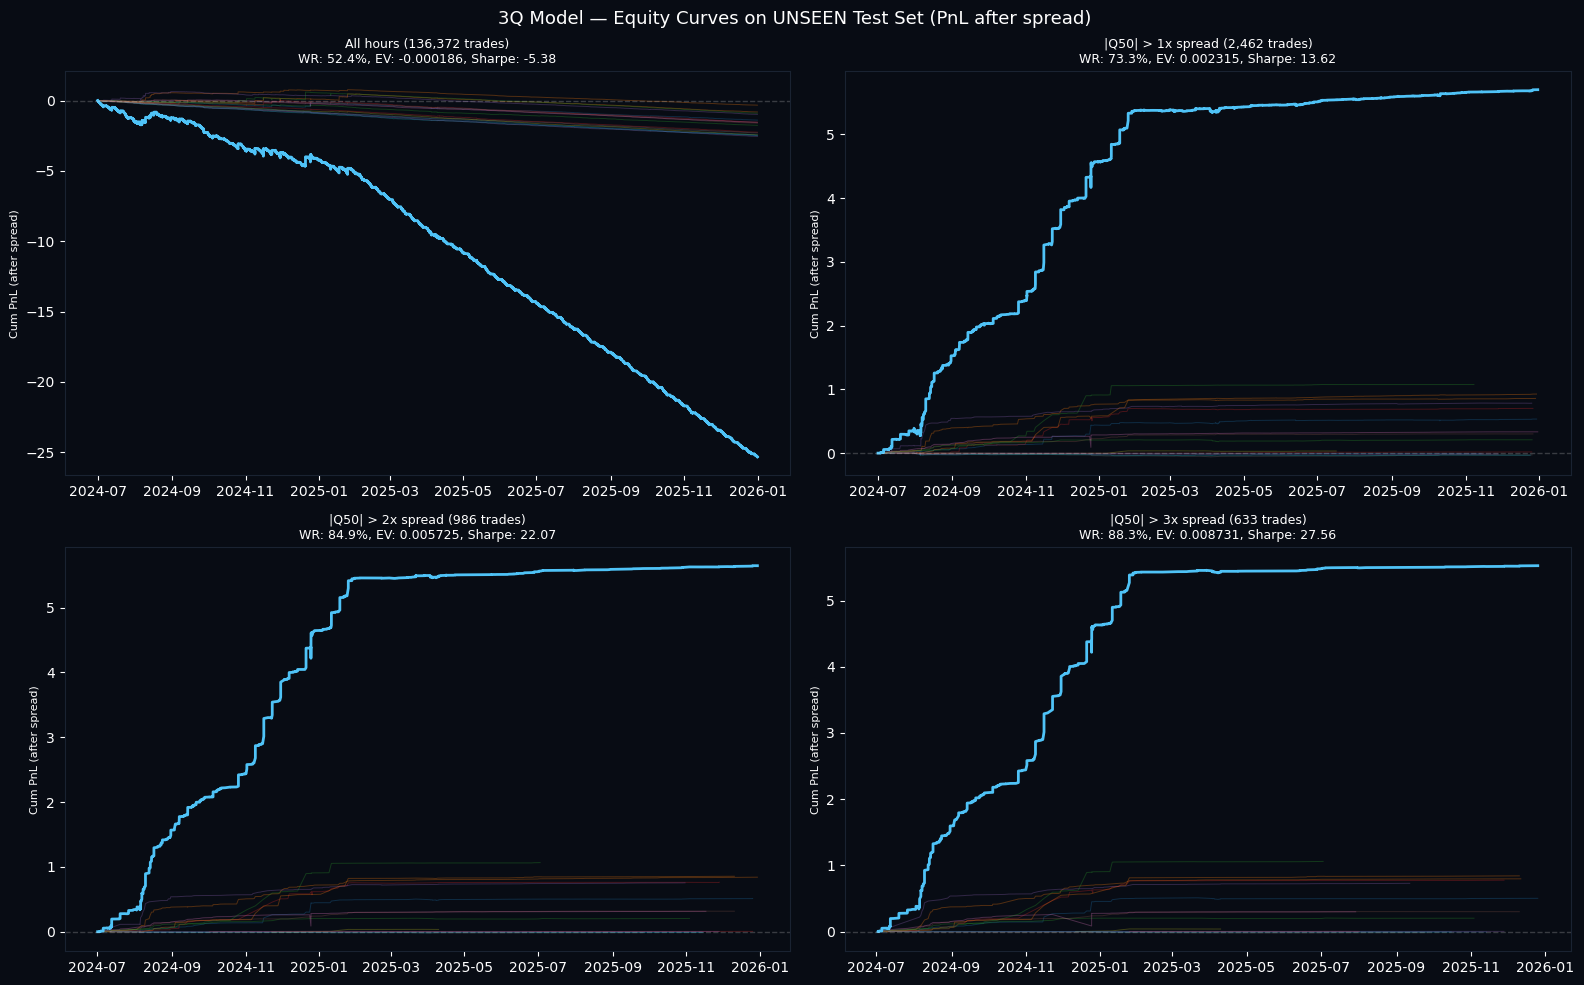

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#080c14')

strategies = {
    'All hours': results,
    f'|Q50| > 1x spread': results[results['abs_Q50'] > AVG_SPREAD],
    f'|Q50| > 2x spread': results[results['abs_Q50'] > AVG_SPREAD * 2],
    f'|Q50| > 3x spread': results[results['abs_Q50'] > AVG_SPREAD * 3],
}

for ax, (name, subset) in zip(axes.flatten(), strategies.items()):
    ax.set_facecolor('#080c14')
    
    pnl = subset['pred_dir'] * subset['actual_return'] - AVG_SPREAD
    cum_pnl = pnl.cumsum()
    
    for pair in sorted(subset['pair'].unique()):
        p = subset[subset['pair'] == pair]
        pair_pnl = (p['pred_dir'] * p['actual_return'] - AVG_SPREAD).cumsum()
        ax.plot(pair_pnl.index, pair_pnl.values, alpha=0.3, linewidth=0.7)
    
    ax.plot(cum_pnl.index, cum_pnl.values, color='#4fc3f7', linewidth=2)
    ax.axhline(0, color=(1,1,1,0.2), linewidth=1, linestyle='--')
    
    wr = (subset['pred_dir'] == subset['actual_dir']).mean()
    ev = pnl.mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    
    ax.set_title(f'{name} ({len(subset):,} trades)\nWR: {wr:.1%}, EV: {ev:.6f}, Sharpe: {sharpe:.2f}', color='white', fontsize=9)
    ax.tick_params(colors='white')
    ax.set_ylabel('Cum PnL (after spread)', color='white', fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('3Q Model — Equity Curves on UNSEEN Test Set (PnL after spread)', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature Importance

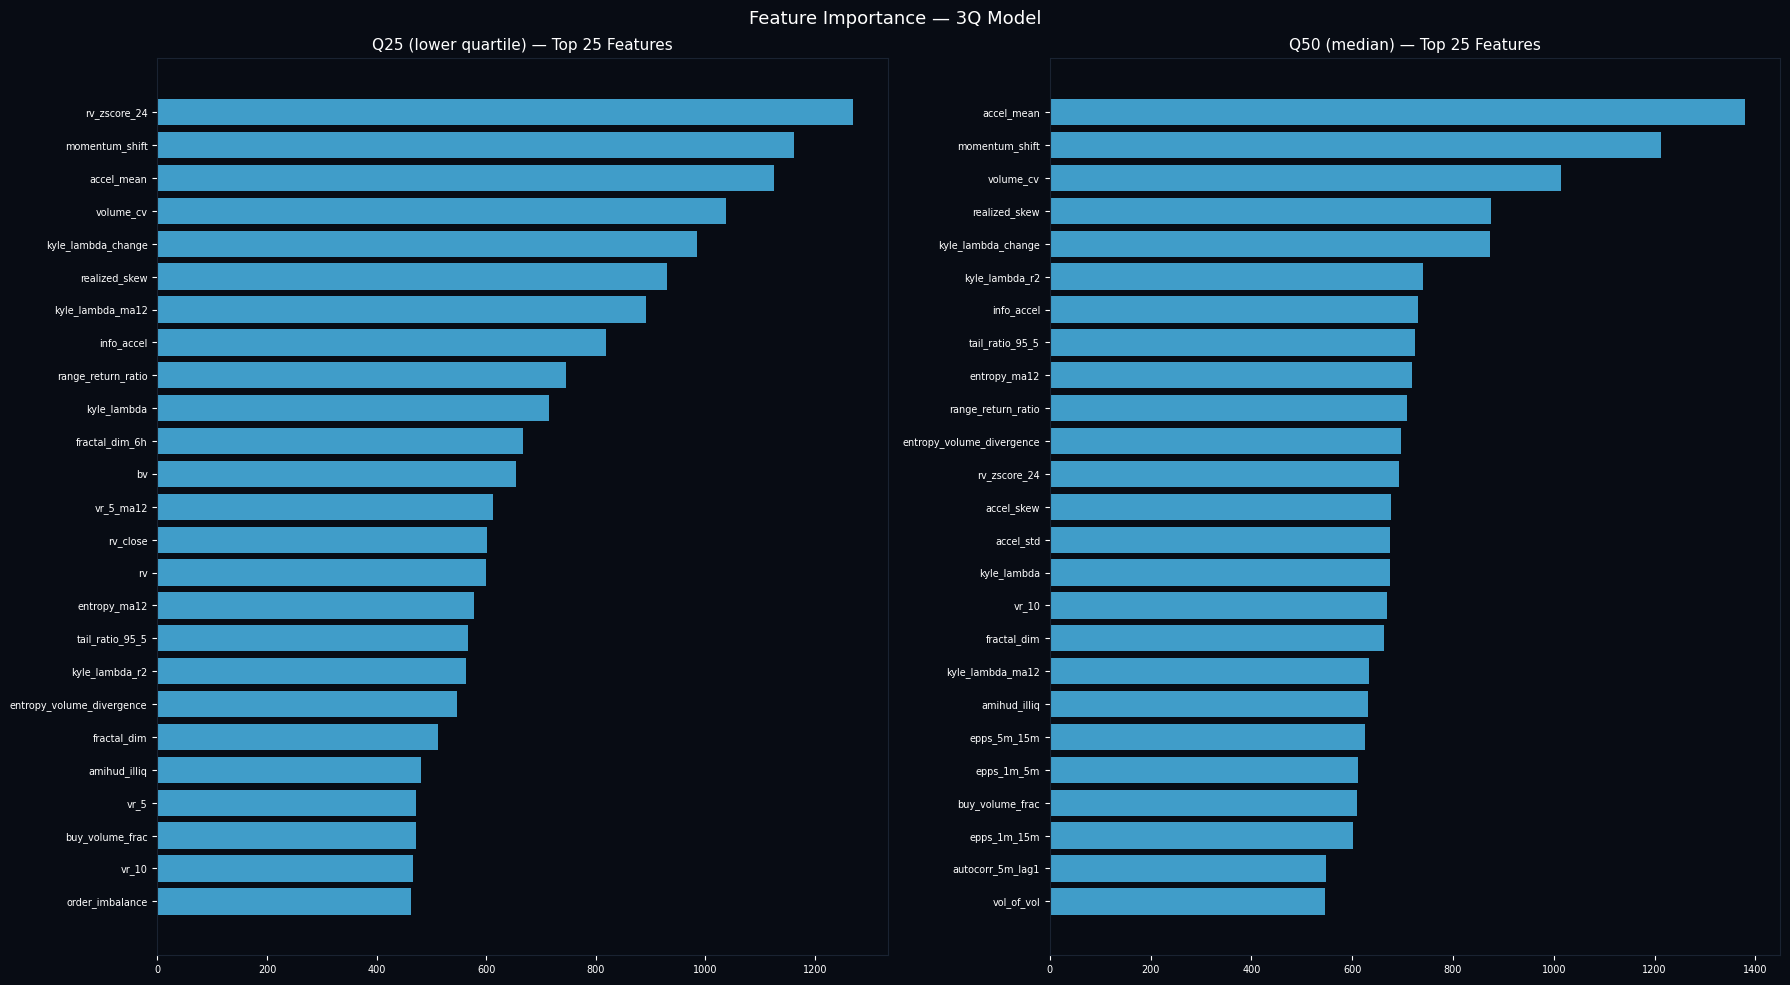

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#080c14')

for ax, (q_name, q_int) in zip(axes, [('Q25 (lower quartile)', 25), ('Q50 (median)', 50)]):
    bundle = joblib.load(MODELS_DIR / f'model_1H_Q{q_int}.joblib')
    importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(25)
    
    ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=7)
    ax.set_title(f'{q_name} — Top 25 Features', color='white', fontsize=11)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Importance — 3Q Model', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Diagnostics

Test Set Quantile Coverage:
Quantile   Target     Actual     Gap
------------------------------------------
Q25        0.25       0.243      -0.007  OK
Q50        0.50       0.495      -0.005  OK
Q75        0.75       0.748      -0.002  OK


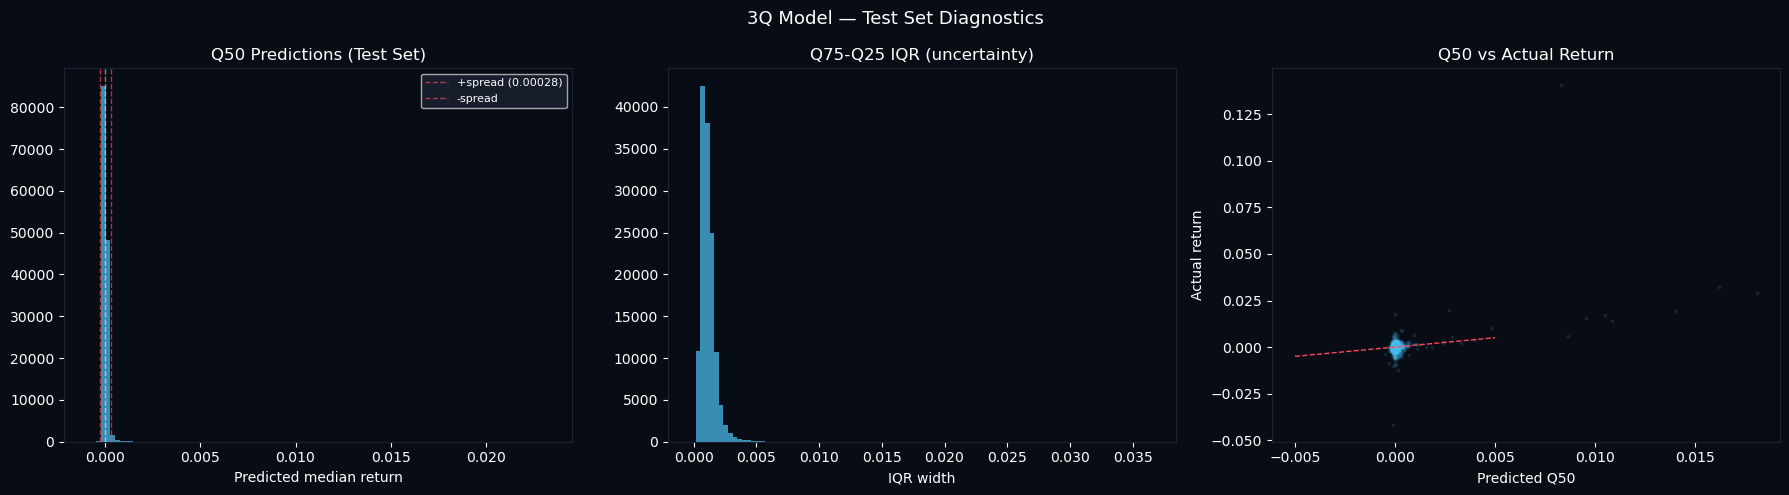

In [11]:
# Test set coverage check
print('Test Set Quantile Coverage:')
print(f'{"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
print(f'{"-"*42}')

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    coverage = (results['actual_return'] <= results[q_name]).mean()
    gap = coverage - q
    flag = 'OK' if abs(gap) < 0.03 else 'DRIFT'
    print(f'{q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')

# Q50 prediction distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Q50 histogram
axes[0].hist(results['Q50'], bins=100, color='#4fc3f7', alpha=0.7, edgecolor='none')
axes[0].axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
axes[0].axvline(AVG_SPREAD, color='#ff4757', linewidth=1, linestyle='--', alpha=0.7, label=f'+spread ({AVG_SPREAD:.5f})')
axes[0].axvline(-AVG_SPREAD, color='#ff4757', linewidth=1, linestyle='--', alpha=0.7, label=f'-spread')
axes[0].set_title('Q50 Predictions (Test Set)', color='white')
axes[0].set_xlabel('Predicted median return', color='white')
axes[0].legend(facecolor='#1a2332', labelcolor='white', fontsize=8)

# IQR histogram
axes[1].hist(results['iqr'], bins=100, color='#4fc3f7', alpha=0.7, edgecolor='none')
axes[1].set_title('Q75-Q25 IQR (uncertainty)', color='white')
axes[1].set_xlabel('IQR width', color='white')

# Q50 vs actual scatter
sample = results.sample(min(5000, len(results)), random_state=42)
axes[2].scatter(sample['Q50'], sample['actual_return'], alpha=0.1, s=3, color='#4fc3f7')
axes[2].plot([-0.005, 0.005], [-0.005, 0.005], '--', color='#ff4757', linewidth=1)
axes[2].set_title('Q50 vs Actual Return', color='white')
axes[2].set_xlabel('Predicted Q50', color='white')
axes[2].set_ylabel('Actual return', color='white')

plt.suptitle('3Q Model — Test Set Diagnostics', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Comparison vs 5Q Model

Load 5Q model predictions and compare side-by-side.

In [12]:
# Load 5Q models for comparison
MODELS_5Q_DIR = Path('../backend/models_5')

q5_preds = {}
for q_name, q_int in [("Q50", 50)]:
    try:
        bundle = joblib.load(MODELS_5Q_DIR / f'model_1H_Q{q_int}.joblib')
        q5_preds[q_name] = bundle['model'].predict(X_test_clean)
    except Exception as e:
        print(f"Could not load 5Q {q_name}: {e}")

if "Q50" in q5_preds:
    pred_dir_5q = np.sign(q5_preds["Q50"])
    abs_q50_5q = np.abs(q5_preds["Q50"])

    # Compare at each threshold
    print(f'\n{"":<25} {"--- 3Q Model ---":>30} {"--- 5Q Model ---":>30}')
    print(f'{"Filter":<25} {"Trades":>8} {"WR":>8} {"EV":>12} {"Trades":>8} {"WR":>8} {"EV":>12}')
    print('-' * 95)

    for name, thresh in thresholds.items():
        # 3Q
        m3 = results['abs_Q50'] > thresh
        if m3.sum() < 50: continue
        s3 = results[m3]
        pnl3 = s3['pred_dir'] * s3['actual_return'] - AVG_SPREAD
        wr3 = (s3['pred_dir'] == s3['actual_dir']).mean()

        # 5Q
        m5 = abs_q50_5q > thresh
        if m5.sum() < 50: continue
        pnl5 = pred_dir_5q[m5] * y_test_clean.values[m5] - AVG_SPREAD
        wr5 = (pred_dir_5q[m5] == np.sign(y_test_clean.values[m5])).mean()

        print(f'{name:<25} {m3.sum():>8,} {wr3:>7.1%} {pnl3.mean():>12.6f} {m5.sum():>8,} {wr5:>7.1%} {pnl5.mean():>12.6f}')
else:
    print("5Q models not found — skipping comparison")


                                        --- 3Q Model ---               --- 5Q Model ---
Filter                      Trades       WR           EV   Trades       WR           EV
-----------------------------------------------------------------------------------------------
All hours (no filter)      136,372   52.4%    -0.000186  136,372   51.9%    -0.000202
|Q50| > 0.5x spread          9,145   61.9%     0.000543    5,940   63.8%     0.000862
|Q50| > 1x spread            2,462   73.3%     0.002315    1,712   77.8%     0.003291
|Q50| > 2x spread              986   84.9%     0.005725      694   91.4%     0.008076
|Q50| > 3x spread              633   88.3%     0.008731      502   94.6%     0.011293
|Q50| > 5x spread              418   93.8%     0.012984      367   97.8%     0.014830


## 11. Summary

In [13]:
print('=' * 70)
print('3-QUANTILE MICROSTRUCTURE MODEL — TRAINING COMPLETE')
print('=' * 70)

print(f'\nModels saved to: {MODELS_DIR.resolve()}')
for f in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'  {f.name:<25} {f.stat().st_size / 1024 / 1024:.1f} MB')

print(f'\n-- CV Results --')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'  {q_name}: pinball={np.mean(cv_pinball[q]):.6f}, avg_iters={int(np.mean(best_iters[q]))}')

print(f'\n-- Test Set Results (UNSEEN, after {TRAIN_END}) --')
best_name, best_ev, best_wr, best_sharpe = '', -999, 0, 0
for name, thresh in thresholds.items():
    mask = results['abs_Q50'] > thresh
    if mask.sum() < 50: continue
    s = results[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    ev = pnl.mean()
    wr = (s['pred_dir'] == s['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    if ev > best_ev:
        best_name, best_ev, best_wr, best_sharpe = name, ev, wr, sharpe

print(f'  Best config:  {best_name}')
print(f'  Win rate:     {best_wr:.1%}')
print(f'  EV/trade:     {best_ev:.6f}')
print(f'  Sharpe:       {best_sharpe:.2f}')
print(f'  Spread cost:  {AVG_SPREAD:.5f}')

print(f'\nTest period: {results.index.min().date()} -> {results.index.max().date()}')
print(f'Training cutoff: {TRAIN_END}')
print(f'Features: {len(feature_cols)} microstructure features')
print(f'Quantiles: {QUANTILE_NAMES}')

3-QUANTILE MICROSTRUCTURE MODEL — TRAINING COMPLETE

Models saved to: C:\Users\noual\lumeny\backend\models_5.1\3_quants
  model_1H_Q25.joblib       2.8 MB
  model_1H_Q50.joblib       3.2 MB
  model_1H_Q75.joblib       4.0 MB

-- CV Results --
  Q25: pinball=0.000327, avg_iters=502
  Q50: pinball=0.000385, avg_iters=634
  Q75: pinball=0.000313, avg_iters=732

-- Test Set Results (UNSEEN, after 2024-06-30) --
  Best config:  |Q50| > 5x spread
  Win rate:     93.8%
  EV/trade:     0.012984
  Sharpe:       34.40
  Spread cost:  0.00028

Test period: 2024-07-01 -> 2025-12-31
Training cutoff: 2024-06-30
Features: 64 microstructure features
Quantiles: ['Q25', 'Q50', 'Q75']
